In [20]:
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV

In [21]:
insurance_data = pd.read_csv("insurance.csv")


insurance_data = pd.read_csv("insurance.csv")

X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

X = pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int)

X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

MSE for alpha 0.1:  20921803.698431376
MSE for alpha 2:  20908106.77995452
MSE for alpha 3:  20901927.931570224
MSE for alpha 0.04:  20922285.53515639
MSE for alpha 50:  21196929.86960891
MSE for alpha 60:  21396196.93989492
MSE for alpha 70:  21634290.38515847
MSE for alpha 80:  21860927.299760208
MSE for alpha 10:  20872844.794796687


<Axes: >

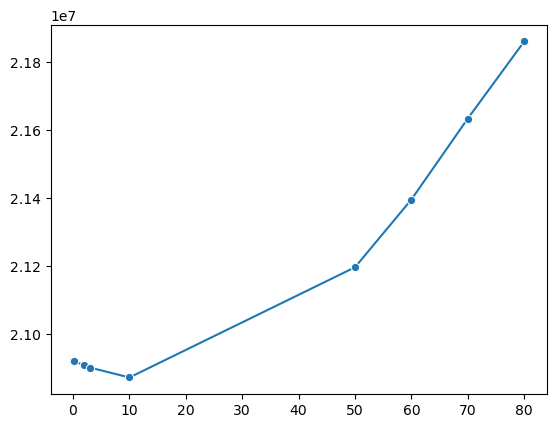

In [22]:
import seaborn as sns

alphas = [0.1, 2, 3, 0.04, 50, 60, 70, 80 ,10]
mses = []

for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train, y_train)

    y_test_pred = lasso_model.predict(X_test)

    mse = mean_squared_error(y_test, y_test_pred)
    print(f"MSE for alpha {a}: " , mse)

    mses.append(mse)

sns.lineplot(x=alphas, y=mses, marker="o")

In [29]:

alphas = [0.001, 0.01, 0.1, 0.02, 0.04, 2, 3, 50, 60, 70, 80]

#lasso_cv_model = LassoCV(alphas=a)

lasso_cv_model = LassoCV(
    alphas=alphas,
    cv=5,
    max_iter=1000,
    random_state=42,
)

lasso_cv_model.fit(X_train, y_train)


print(f"best alpha {a}: " , lasso_cv_model.alpha_)

y_test_pred = lasso_model.predict(X_test)

mse = mean_squared_error(y_test, y_test_pred)

print(f"MSE for alpha {a}: " , mse)


r2 = r2_score(y_test, y_test_pred) 
print("r2_score : ",r2)

#sns.lineplot(x=alphas, y=mses, marker="o")

best alpha 10:  0.001
MSE for alpha 10:  20872844.794796687
r2_score :  0.8655522361166428
